In [27]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

chart_path = BASE_DIR / "reports" / "charts"

print(chart_path)
print(chart_path.exists())

c:\Users\hamma\OneDrive\Desktop\bluestock_mf_capstone\reports\charts
True


Insight 10:
Funds with higher Sharpe ratios generally demonstrated better risk-adjusted performance.

Insight 9:
T30 cities accounted for a substantial share of investments, although B30 participation also showed strong growth.

Insight 8:
Investment amounts varied across age groups, with middle-aged investors generally contributing higher SIP amounts.

Insight 7:
The 26–35 and 36–45 age groups contributed the largest proportion of mutual fund investors.

Insight 6:
Financials, Technology, and Healthcare sectors represented a significant share of portfolio allocations.

Insight 5:
Industry folio counts nearly doubled over the observed period, showing rapid expansion of the mutual fund investor base.

Insight 4:
Certain fund categories consistently attracted higher net inflows compared to others, indicating investor preference patterns.

Insight 3:
Monthly SIP inflows increased steadily over time, reflecting growing retail investor participation.

Insight 2:
SBI Mutual Fund maintained the highest AUM among all fund houses, demonstrating market leadership.

Insight 1:
NAV values showed an overall upward trend between 2022 and 2026, indicating long-term growth in mutual fund investments.

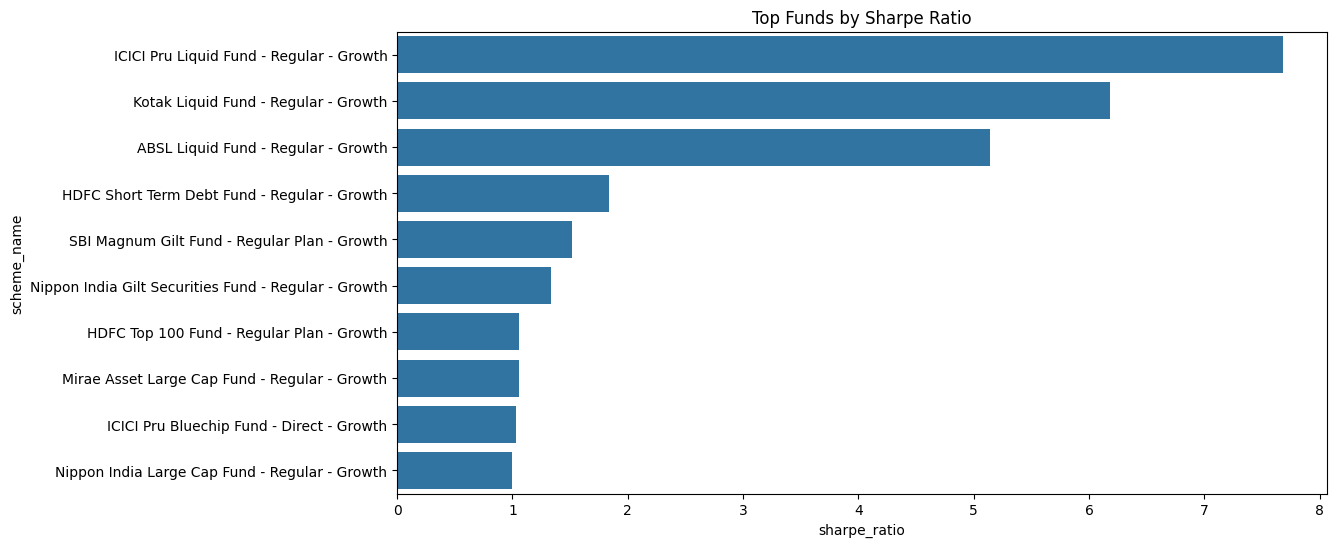

In [25]:
top_sharpe = performance.nlargest(
    10,
    "sharpe_ratio"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top Funds by Sharpe Ratio")

plt.show()

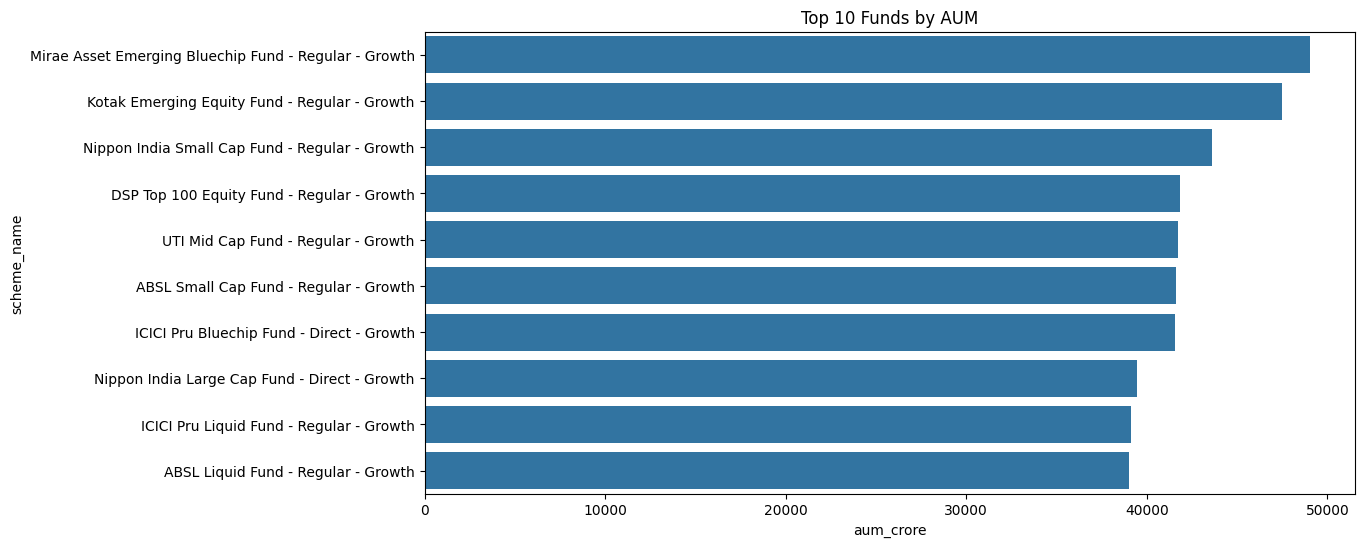

In [24]:
top_funds = performance.nlargest(
    10,
    "aum_crore"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.show()

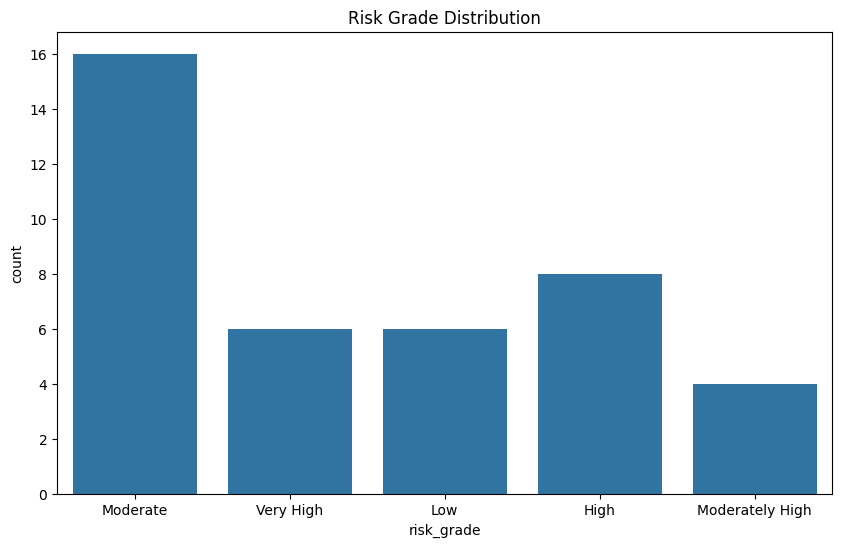

In [21]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.show()

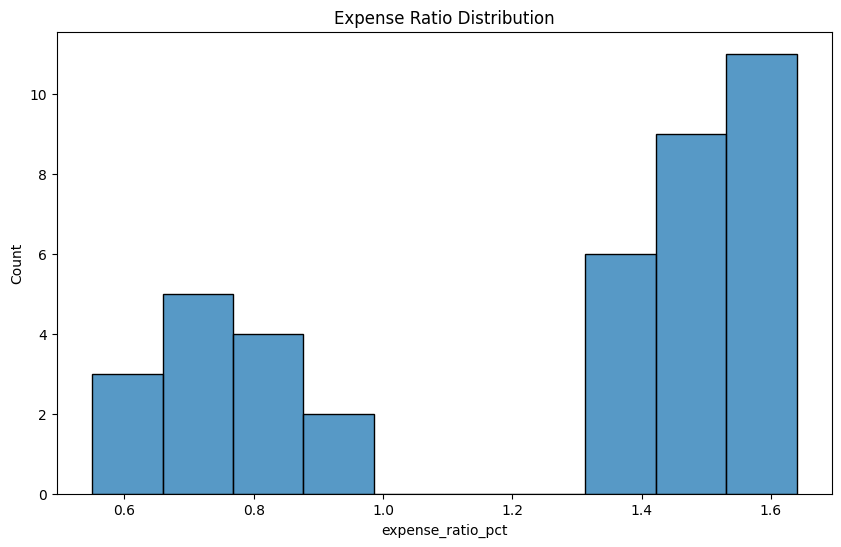

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10
)

plt.title("Expense Ratio Distribution")

plt.show()

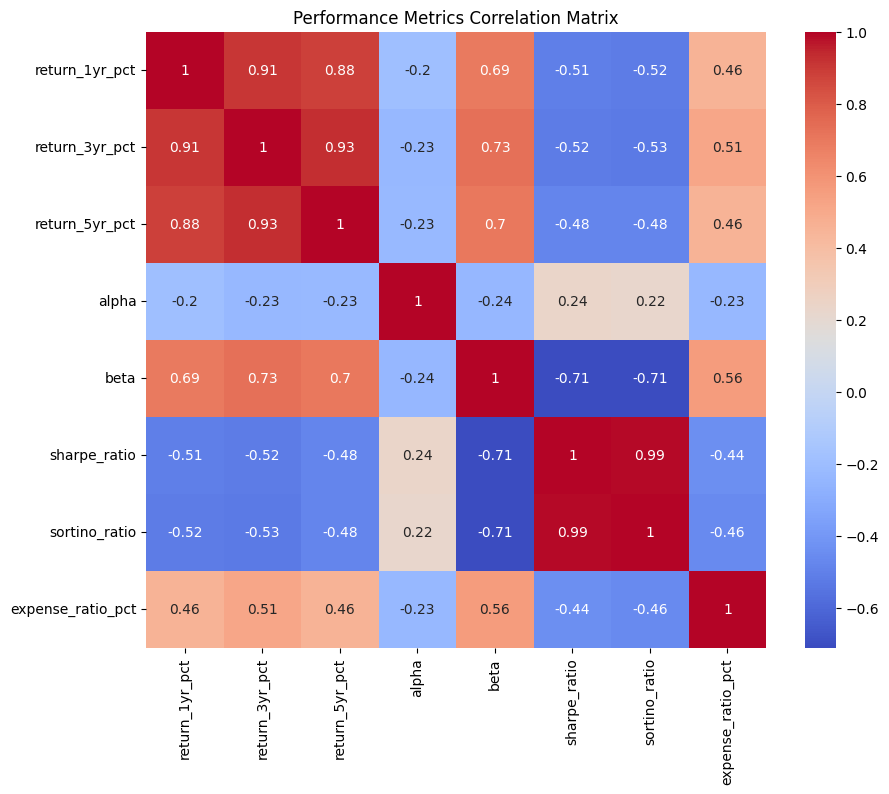

In [19]:
corr_data = performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio",
        "sortino_ratio",
        "expense_ratio_pct"
    ]
]

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Performance Metrics Correlation Matrix")

plt.show()

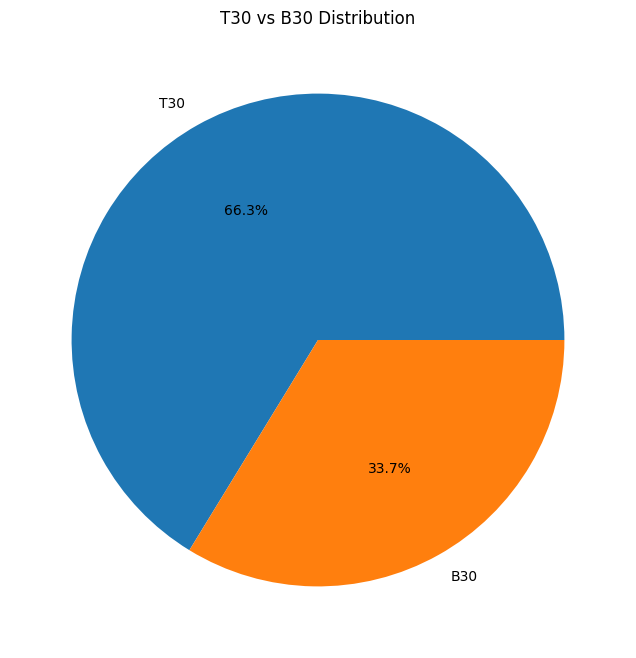

In [17]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.show()

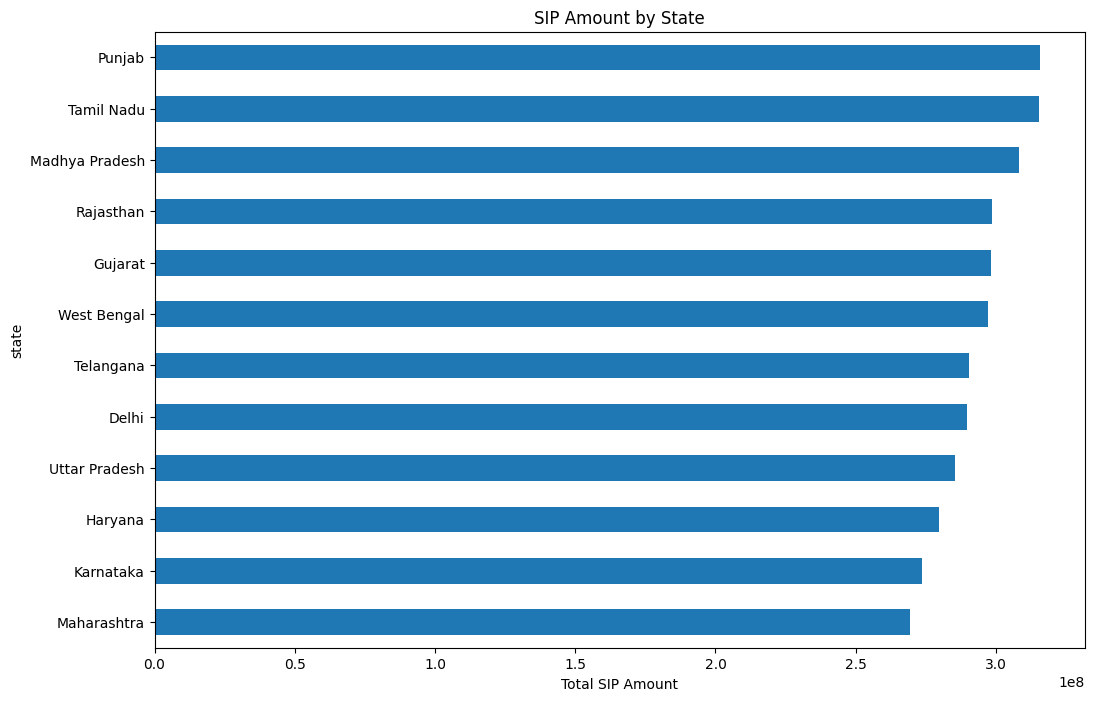

In [16]:
state_sip = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

plt.figure(figsize=(12,8))

state_sip.plot(
    kind="barh"
)

plt.title("SIP Amount by State")

plt.xlabel("Total SIP Amount")

plt.show()

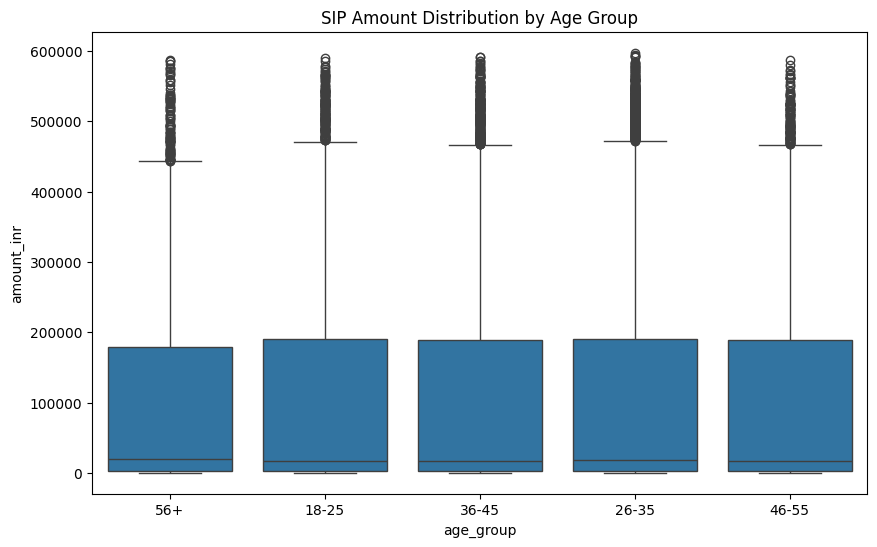

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.show()

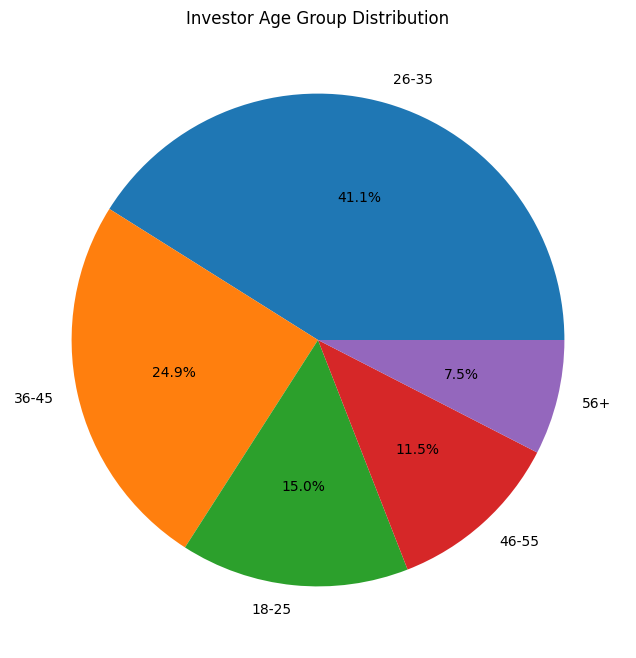

In [35]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    chart_path / "chart_name.png",
    bbox_inches="tight"
)

plt.show()

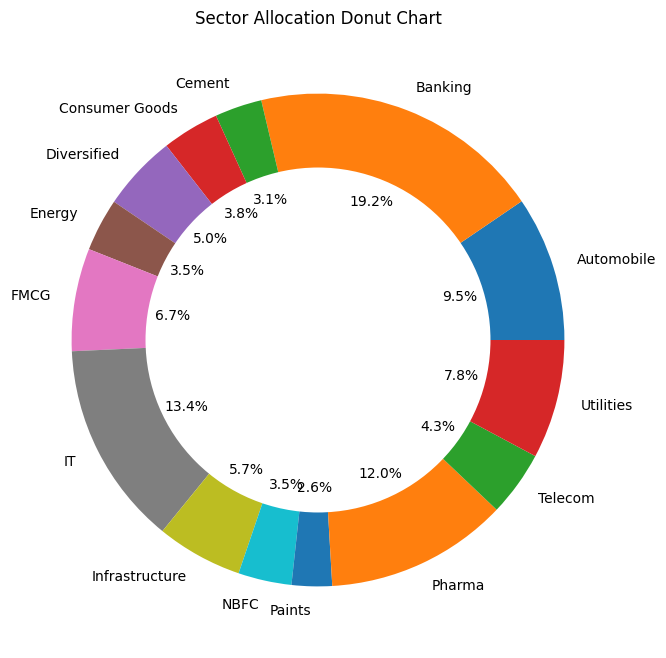

In [ ]:
sector_data = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.show()

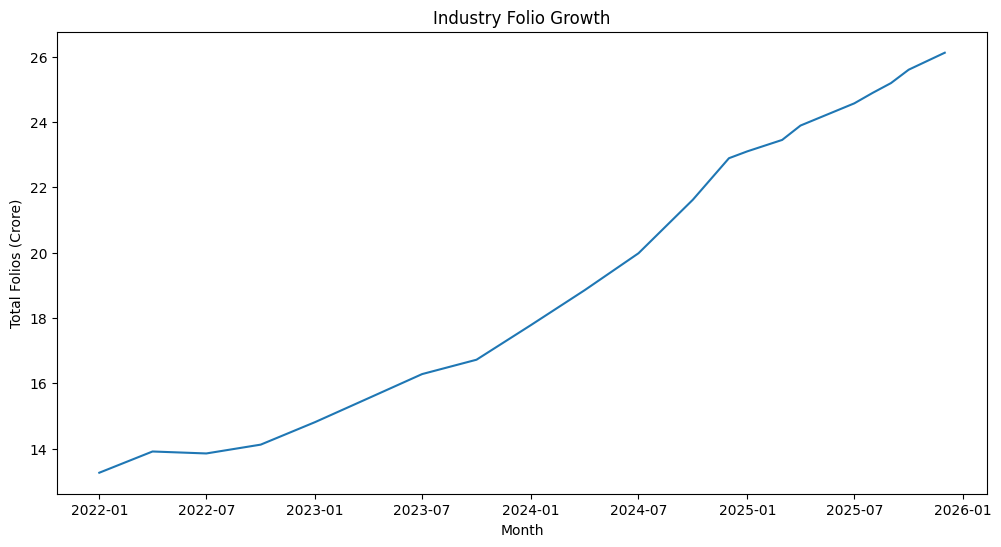

In [ ]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.xlabel("Month")

plt.ylabel("Total Folios (Crore)")


plt.show()

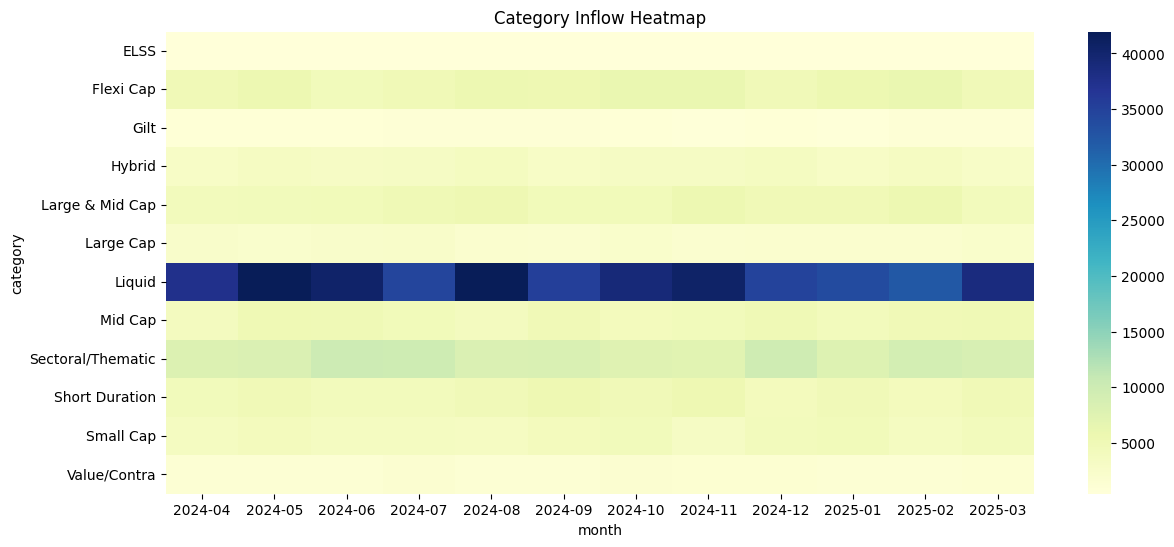

In [ ]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

In [8]:
print(category.columns)

print(folio.columns)

print(portfolio.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


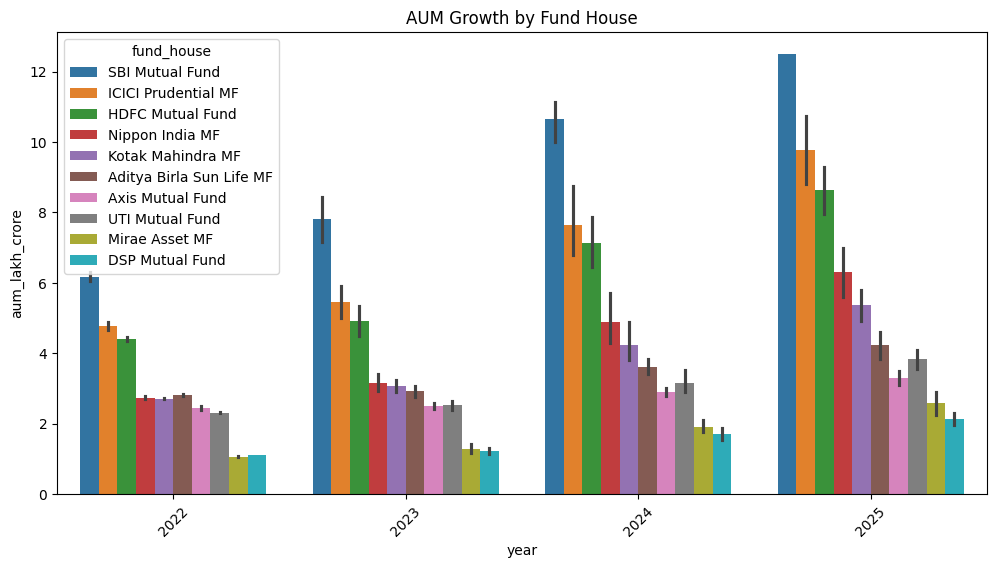

In [36]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House")

plt.savefig(
    chart_path / "aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)
plt.savefig(
    chart_path / "nav_trend.png",
    bbox_inches="tight"
)

fig.show()

<Figure size 640x480 with 0 Axes>

In [3]:
print(nav_history.columns)
print(aum.columns)
print(sip.columns)
print(transactions.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [2]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent

raw_path = BASE_DIR / "data" / "raw"

fund_master = pd.read_csv(raw_path / "01_fund_master.csv")
nav_history = pd.read_csv(raw_path / "02_nav_history.csv")
aum = pd.read_csv(raw_path / "03_aum_by_fund_house.csv")
sip = pd.read_csv(raw_path / "04_monthly_sip_inflows.csv")
category = pd.read_csv(raw_path / "05_category_inflows.csv")
folio = pd.read_csv(raw_path / "06_industry_folio_count.csv")
performance = pd.read_csv(raw_path / "07_scheme_performance.csv")
transactions = pd.read_csv(raw_path / "08_investor_transactions.csv")
portfolio = pd.read_csv(raw_path / "09_portfolio_holdings.csv")
benchmark = pd.read_csv(raw_path / "10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from pathlib import Path

print("Setup Complete")

Setup Complete
